In [1]:
import pandas as pd;
import numpy as np;

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ONINE_FOOD_DELIVERY_ANALYSIS.csv to ONINE_FOOD_DELIVERY_ANALYSIS.csv


In [ ]:
df=pd.read_csv("ONINE_FOOD_DELIVERY_ANALYSIS.csv")

In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [ ]:
df.shape

(100000, 25)

In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin'],
      dtype='object')

In [ ]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Customer_Age,float64
Customer_Gender,object
City,object
Area,object
Restaurant_ID,object
Restaurant_Name,object
Cuisine_Type,object
Order_Date,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

In [ ]:
df.describe()

,Customer_Age,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin
count,49907.000000,66641.000000,66530.000000,66673.000000,83285.000000,44303.000000,83477.000000,100000.000000,100000.000000
mean,38.976516,127.475923,16.449242,2081.830126,93.936243,1961.101190,2.991531,4.249680,0.150362
std,12.372157,90.805839,12.256742,1553.628891,108.209904,1557.354417,1.414108,0.722554,0.201888
min,18.000000,20.000000,1.000000,150.000000,0.000000,-150.000000,1.000000,3.000000,-0.200000
25%,28.000000,45.000000,5.470000,673.000000,20.000000,559.000000,2.000000,3.600000,-0.020000
50%,39.000000,120.000000,9.970000,1197.000000,50.000000,1156.000000,3.000000,4.200000,0.150000
75%,50.000000,210.000000,27.430000,3494.000000,100.000000,3375.000000,4.000000,4.900000,0.320000
max,60.000000,300.000000,40.000000,5000.000000,300.000000,4980.000000,5.000000,5.500000,0.500000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,50093
Customer_Gender,24856
City,16726
Area,16685
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,16885
Order_Date,1014


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Order_Status'].value_counts(dropna=False)

,count
Order_Status,
Delivered,84964
Cancelled,15036


In [ ]:
df.groupby('Order_Status')['Delivery_Time_Min'].apply (lambda x:x.isnull().sum())

,Delivery_Time_Min
Order_Status,
Cancelled,5030
Delivered,28329


In [ ]:
df.groupby('Order_Status')[['Delivery_Time_Min','Distance_km','Order_Value','Final_Amount']].apply (lambda x:x.isnull().sum())

,Delivery_Time_Min,Distance_km,Order_Value,Final_Amount
Order_Status,,,,
Cancelled,5030,5118,5006,8325
Delivered,28329,28352,28321,47372


In [ ]:
df[['Delivery_Time_Min','Distance_km','Order_Value']].isnull().all(axis=1).sum()

np.int64(3660)

In [ ]:
df[
    df[['Delivery_Time_Min', 'Distance_km', 'Order_Value']].isnull().all(axis=1)
]['Order_Status'].value_counts()

,count
Order_Status,
Delivered,3115
Cancelled,545


In [ ]:
df[
    (df['Order_Status'] == 'Delivered') &
    df[['Delivery_Time_Min', 'Distance_km', 'Order_Value']].isnull().all(axis=1)
][['Order_ID', 'Order_Status', 'Final_Amount', 'Payment_Mode', 'Delivery_Rating']].head(10)

,Order_ID,Order_Status,Final_Amount,Payment_Mode,Delivery_Rating
17,ORD000018,Delivered,NaN,Card,5.0
18,ORD000019,Delivered,NaN,Card,1.0
69,ORD000070,Delivered,NaN,UPI,5.0
72,ORD000073,Delivered,NaN,Wallet,1.0
114,ORD000115,Delivered,NaN,COD,1.0
171,ORD000172,Delivered,NaN,Wallet,5.0
213,ORD000214,Delivered,NaN,Wallet,NaN
230,ORD000231,Delivered,NaN,COD,2.0
385,ORD000386,Delivered,NaN,Wallet,1.0
408,ORD000409,Delivered,NaN,UPI,4.0


In [ ]:
df[
    (df['Order_Status'] == 'Delivered') &
    df[['Delivery_Time_Min', 'Distance_km', 'Order_Value']].isnull().all(axis=1)
][[
    'Order_ID',
    'Order_Status',
    'Order_Value',
    'Discount_Applied',
    'Final_Amount',
    'Profit_Margin'
]].head(10)

,Order_ID,Order_Status,Order_Value,Discount_Applied,Final_Amount,Profit_Margin
17,ORD000018,Delivered,NaN,20.0,NaN,-0.09
18,ORD000019,Delivered,NaN,0.0,NaN,-0.16
69,ORD000070,Delivered,NaN,50.0,NaN,-0.17
72,ORD000073,Delivered,NaN,20.0,NaN,-0.09
114,ORD000115,Delivered,NaN,0.0,NaN,-0.11
171,ORD000172,Delivered,NaN,20.0,NaN,0.13
213,ORD000214,Delivered,NaN,20.0,NaN,0.15
230,ORD000231,Delivered,NaN,300.0,NaN,0.44
385,ORD000386,Delivered,NaN,20.0,NaN,0.24
408,ORD000409,Delivered,NaN,NaN,NaN,0.46


In [ ]:
df[
    df[['Order_Value', 'Discount_Applied', 'Final_Amount']].notnull().all(axis=1)
][[
    'Order_Value',
    'Discount_Applied',
    'Final_Amount'
]].head(10)

,Order_Value,Discount_Applied,Final_Amount
1,4869.0,20.0,4849.0
2,757.0,20.0,737.0
4,372.0,20.0,352.0
7,3506.0,20.0,3486.0
8,525.0,100.0,425.0
9,4691.0,50.0,4641.0
10,4881.0,100.0,4781.0
12,417.0,20.0,397.0
14,4017.0,300.0,3717.0
16,4218.0,20.0,4198.0


In [ ]:
df.groupby('Order_Status')['Order_Value'].apply (lambda x: x.isnull().sum())

,Order_Value
Order_Status,
Cancelled,5006
Delivered,28321


In [ ]:
df.groupby('Order_Status')['Final_Amount'].apply(lambda x: x.isnull().sum())

,Final_Amount
Order_Status,
Cancelled,8325
Delivered,47372


In [ ]:
df[
    (df['Order_Status'] == 'Delivered') &
    (df['Final_Amount'].isnull())
][[
    'Order_ID',
    'Order_Value',
    'Discount_Applied',
    'Final_Amount'
]].head(10)

,Order_ID,Order_Value,Discount_Applied,Final_Amount
0,ORD000001,NaN,NaN,NaN
5,ORD000006,NaN,300.0,NaN
6,ORD000007,NaN,0.0,NaN
11,ORD000012,NaN,100.0,NaN
13,ORD000014,NaN,50.0,NaN
17,ORD000018,NaN,20.0,NaN
18,ORD000019,NaN,0.0,NaN
19,ORD000020,NaN,100.0,NaN
23,ORD000024,4014.0,NaN,NaN
24,ORD000025,687.0,NaN,NaN


In [ ]:
df[
    (df['Final_Amount'].isnull()) &
    (df['Order_Value'].notnull()) &
    (df['Discount_Applied'].notnull())
].shape

(11211, 25)

In [ ]:
check = df[
    df[['Order_Value', 'Discount_Applied', 'Final_Amount']].notnull().all(axis=1)
].copy()

check['Calculated_Final_Amount'] = (
    check['Order_Value'] - check['Discount_Applied']
)

(check['Calculated_Final_Amount'] == check['Final_Amount']).sum()

np.int64(44303)

check negative value in final amount

In [ ]:
df[df['Final_Amount'] < 0][
    ['Order_ID', 'Order_Status', 'Order_Value',
     'Discount_Applied', 'Final_Amount']
].head(10)

,Order_ID,Order_Status,Order_Value,Discount_Applied,Final_Amount
104,ORD000105,Delivered,187.0,300.0,-113.0
132,ORD000133,Delivered,175.0,300.0,-125.0
284,ORD000285,Delivered,246.0,300.0,-54.0
306,ORD000307,Delivered,194.0,300.0,-106.0
359,ORD000360,Delivered,285.0,300.0,-15.0
576,ORD000577,Delivered,247.0,300.0,-53.0
619,ORD000620,Delivered,234.0,300.0,-66.0
729,ORD000730,Delivered,210.0,300.0,-90.0
891,ORD000892,Cancelled,195.0,300.0,-105.0
1148,ORD001149,Delivered,204.0,300.0,-96.0


check wherther it is discount applied or percentage

In [ ]:
Final_Amount = max(Order_Value - Discount_Applied, 0)

NameError: name 'Order_Value' is not defined

oder value missing

In [ ]:

df['Order_Value'].isna().sum()

np.int64(33327)

discount applied missing value

In [ ]:
df['Discount_Applied'].isna().sum()

np.int64(16715)

negative final value missing

In [ ]:
(df['Final_Amount'] < 0).sum()

np.int64(0)

In [ ]:
df[df['Order_Value'].isna()]['Order_Status'].value_counts(dropna=False)

,count
Order_Status,
Delivered,28321
Cancelled,5006


In [ ]:
df[df['Discount_Applied'].isna()]['Order_Status'].value_counts(dropna=False)

,count
Order_Status,
Delivered,14129
Cancelled,2586


In [ ]:
df[['Order_Value', 'Discount_Applied', 'Final_Amount']].isna().sum()

,0
Order_Value,33327
Discount_Applied,16715
Final_Amount,44486


In [ ]:
df[df['Final_Amount'].isna()][
    ['Order_Value', 'Discount_Applied', 'Final_Amount']
].isna().sum()

,0
Order_Value,33327
Discount_Applied,16715
Final_Amount,44486


analysis process

In [ ]:
analysis_df = df.dropna(
    subset=['Order_Value', 'Discount_Applied', 'Final_Amount']
).copy()

In [ ]:
analysis_df.shape

(55514, 25)

check avegof order value in status

In [ ]:
analysis_df.groupby('Order_Status')['Order_Value'].agg(
    ['count', 'sum', 'mean']
).round(2)

,count,sum,mean
Order_Status,,,
Cancelled,8340,17195065.0,2061.76
Delivered,47174,98014304.0,2077.72


Insight: Delivered orders have a slightly higher average order value (2,077.72) compared with cancelled orders (2,061.76). Delivered orders also account for a much larger total order value in the analyzed records.

In [ ]:
analysis_df.columns.tolist()

['Order_ID',
 'Customer_ID',
 'Customer_Age',
 'Customer_Gender',
 'City',
 'Area',
 'Restaurant_ID',
 'Restaurant_Name',
 'Cuisine_Type',
 'Order_Date',
 'Order_Time',
 'Delivery_Time_Min',
 'Distance_km',
 'Order_Value',
 'Discount_Applied',
 'Final_Amount',
 'Payment_Mode',
 'Order_Status',
 'Cancellation_Reason',
 'Delivery_Partner_ID',
 'Delivery_Rating',
 'Restaurant_Rating',
 'Order_Day',
 'Peak_Hour',
 'Profit_Margin']

CUSINE COLUMN ANALYSIS

In [ ]:
analysis_df.groupby('Cuisine_Type')['Order_Value'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False).round(2)

,count,sum,mean
Cuisine_Type,,,
Indian,9377,19523331.0,2082.04
Mexican,9333,19430272.0,2081.89
Chinese,9242,19135349.0,2070.48
Arabian,9243,19031571.0,2059.03
Italian,8978,18519385.0,2062.75


In [ ]:
df.duplicated().sum()

np.int64(0)

Pre-processing — Rating Validation

In [ ]:
df[['Delivery_Rating', 'Restaurant_Rating']].agg(['min', 'max'])

,Delivery_Rating,Restaurant_Rating
min,1.0,3.0
max,5.0,5.5


In [ ]:
df[df['Restaurant_Rating'] > 5]['Restaurant_Rating'].value_counts().sort_index()

,count
Restaurant_Rating,
5.1,4031
5.2,4054
5.3,4016
5.4,3876
5.5,2042


In [ ]:
df['Restaurant_Rating'].value_counts().sort_index()

,count
Restaurant_Rating,
3.0,2002
3.1,4047
3.2,3985
3.3,3904
3.4,4005
3.5,3969
3.6,4085
3.7,3980
3.8,4080


In [ ]:
df['Final_Amount'].min()

0.0

In [ ]:
Categorical Data Quality Check

In [ ]:
df['Order_Status'].value_counts()

,count
Order_Status,
Delivered,84964
Cancelled,15036


In [ ]:
df['Payment_Mode'].value_counts()

,count
Payment_Mode,
Card,20094
Wallet,20086
COD,19977
UPI,19932


missing Payment_Mode

In [ ]:
df['Payment_Mode'].isna().sum()

np.int64(19911)

In [ ]:
clean_df = df.copy()

Payment Mode

In [ ]:
clean_df['Payment_Mode'] = clean_df['Payment_Mode'].fillna('Unknown')

In [ ]:
clean_df['Payment_Mode'].value_counts()

,count
Payment_Mode,
Card,20094
Wallet,20086
COD,19977
UPI,19932
Unknown,19911


Pre-processing — Customer_Gender

In [ ]:
clean_df['Customer_Gender'].value_counts(dropna=False)

,count
Customer_Gender,
Other,25135
Female,25031
Male,24978
NaN,24856


In [ ]:
clean_df['Customer_Gender'] = clean_df['Customer_Gender'].fillna('Unknown')

In [ ]:
clean_df['Customer_Gender'].value_counts()

,count
Customer_Gender,
Other,25135
Female,25031
Male,24978
Unknown,24856


cancelation reason

In [ ]:
clean_df.groupby('Order_Status')['Cancellation_Reason'].apply(
    lambda x: x.isna().sum()
)

,Cancellation_Reason
Order_Status,
Cancelled,6005
Delivered,84964


In [ ]:
clean_df.loc[
    clean_df['Order_Status'] == 'Cancelled',
    'Cancellation_Reason'
] = clean_df.loc[
    clean_df['Order_Status'] == 'Cancelled',
    'Cancellation_Reason'
].fillna('Unknown')

In [ ]:
clean_df.groupby('Order_Status')['Cancellation_Reason'].apply(
    lambda x: x.isna().sum()
)

,Cancellation_Reason
Order_Status,
Cancelled,0
Delivered,84964


In [ ]:
clean_df[
    clean_df['Order_Status'] == 'Cancelled'
][['Order_Status', 'Cancellation_Reason']].head(20)

,Order_Status,Cancellation_Reason
3,Cancelled,Late Delivery
15,Cancelled,Restaurant Issue
31,Cancelled,Unknown
36,Cancelled,Customer Cancelled
38,Cancelled,Unknown
49,Cancelled,Unknown
54,Cancelled,Customer Cancelled
60,Cancelled,Unknown
73,Cancelled,Customer Cancelled
81,Cancelled,Unknown


Pre-processing: Date & Time

In [ ]:
clean_df[['Order_Date','Order_Time']].dtypes

,0
Order_Date,object
Order_Time,object


In [ ]:
clean_df['Order_Date']=pd.to_datetime(clean_df['Order_Date'])

In [ ]:
clean_df['Order_Date'].dtypes

dtype('<M8[ns]')

In [ ]:
clean_df['Order_Time'].head(10)

,Order_Time
0,0:00
1,0:00
2,0:00
3,0:00
4,0:00
...,...
95,0:00
96,0:00
97,0:00
98,0:00


In [ ]:
clean_df['Order_Time'].isna().sum()

np.int64(1998)

In [ ]:
clean_df['Order_Time'].dtype

dtype('O')

In [ ]:
clean_df['Order_Time'].unique()

array(['0:00', nan], dtype=object)

In [ ]:
clean_df = clean_df.drop(columns=['Order_Time'])

In [ ]:
'Order_Time' in clean_df.columns

False

customer age

In [ ]:
clean_df['Customer_Age'].agg(['min', 'max'])

,Customer_Age
min,18.0
max,60.0


In [ ]:
clean_df['Customer_Age'].isna().sum()

np.int64(50093)

In [ ]:
clean_df.groupby('Order_Status')['Customer_Age'].apply(
    lambda x: x.isna().sum()
)

,Customer_Age
Order_Status,
Cancelled,7565
Delivered,42528


Delivery_Time_Min

In [ ]:
clean_df['Delivery_Time_Min'].agg(['min', 'max'])

,Delivery_Time_Min
min,20.0
max,300.0


In [ ]:
clean_df['Delivery_Time_Min'].isna().sum()

np.int64(33359)

In [ ]:
clean_df.groupby('Order_Status')['Delivery_Time_Min'].apply(
    lambda x: x.isna().sum()
)

,Delivery_Time_Min
Order_Status,
Cancelled,5030
Delivered,28329


Distance_km

In [ ]:
clean_df['Distance_km'].agg(['min', 'max'])

,Distance_km
min,1.0
max,40.0


In [ ]:
clean_df['Distance_km'].isna().sum()

np.int64(33470)

In [ ]:
clean_df.groupby('Order_Status')['Distance_km'].apply(
    lambda x: x.isna().sum()
)

,Distance_km
Order_Status,
Cancelled,5118
Delivered,28352


In [ ]:
clean_df['Order_Value'].agg(['min', 'max'])

,Order_Value
min,150.0
max,5000.0


In [ ]:
clean_df.groupby('Order_Status')['Order_Value'].apply(
    lambda x: x.isna().sum()
)

,Order_Value
Order_Status,
Cancelled,5006
Delivered,28321


In [ ]:
df.shape

(100000, 25)

In [ ]:

print("Negative Final_Amount:",
      (df['Final_Amount'] < 0).sum())


print("Discount > Order_Value:",
      (df['Discount_Applied'] > df['Order_Value']).sum())
print("Negative Order_Value:",
      (df['Order_Value'] < 0).sum())


display(
    df.loc[df['Final_Amount'] < 0,
           ['Order_ID', 'Order_Status', 'Order_Value',
            'Discount_Applied', 'Final_Amount']].head(10)
)

Negative Final_Amount: 773
Discount > Order_Value: 773
Negative Order_Value: 0


,Order_ID,Order_Status,Order_Value,Discount_Applied,Final_Amount
104,ORD000105,Delivered,187.0,300.0,-113.0
132,ORD000133,Delivered,175.0,300.0,-125.0
284,ORD000285,Delivered,246.0,300.0,-54.0
306,ORD000307,Delivered,194.0,300.0,-106.0
359,ORD000360,Delivered,285.0,300.0,-15.0
576,ORD000577,Delivered,247.0,300.0,-53.0
619,ORD000620,Delivered,234.0,300.0,-66.0
729,ORD000730,Delivered,210.0,300.0,-90.0
891,ORD000892,Cancelled,195.0,300.0,-105.0
1148,ORD001149,Delivered,204.0,300.0,-96.0


In [ ]:
# Create cleaned columns
df['Discount_Applied_Clean'] = df['Discount_Applied'].copy()

# Cap discount at the order value
mask = (
    df['Order_Value'].notna() &
    df['Discount_Applied_Clean'].notna() &
    (df['Discount_Applied_Clean'] > df['Order_Value'])
)

df.loc[mask, 'Discount_Applied_Clean'] = (
    df.loc[mask, 'Order_Value']
)

# Recalculate Final_Amount
df['Final_Amount_Clean'] = (
    df['Order_Value'] - df['Discount_Applied_Clean']
).clip(lower=0)

# Validate
print("Invalid discounts remaining:",
      (df['Discount_Applied_Clean'] > df['Order_Value']).sum())

print("Negative final amounts remaining:",
      (df['Final_Amount_Clean'] < 0).sum())

print("Rows corrected:", mask.sum())

Invalid discounts remaining: 0
Negative final amounts remaining: 0
Rows corrected: 773


In [ ]:
# Identify rows where Final_Amount is missing
# but Order_Value and Discount_Applied are available
mask = (
    df['Final_Amount_Clean'].isna() &
    df['Order_Value'].notna() &
    df['Discount_Applied_Clean'].notna()
)

# Calculate the missing final amounts
df.loc[mask, 'Final_Amount_Clean'] = (
    df.loc[mask, 'Order_Value'] -
    df.loc[mask, 'Discount_Applied_Clean']
).clip(lower=0)

print("Final amounts calculated:", mask.sum())
print("Missing Final_Amount before:", df['Final_Amount'].isna().sum())
print("Missing Final_Amount after:", df['Final_Amount_Clean'].isna().sum())

Final amounts calculated: 0
Missing Final_Amount before: 55697
Missing Final_Amount after: 44486


feature engineering

In [ ]:
# Create age groups
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=[
        'Under 18',
        '18-30',
        '31-45',
        '46-60',
        'Above 60'
    ],
    include_lowest=True
)

# Check the result
print(df['Age_Group'].value_counts(dropna=False))

Age_Group
NaN         50093
31-45       17445
46-60       17386
18-30       13919
Under 18     1157
Above 60        0
Name: count, dtype: int64


In [ ]:
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[-1, 17, 30, 45, 60, float('inf')],
    labels=[
        'Under 18',
        '18-30',
        '31-45',
        '46-60',
        'Above 60'
    ]
)

print(df['Age_Group'].value_counts(dropna=False))

Age_Group
NaN         50093
31-45       17445
46-60       17386
18-30       15076
Under 18        0
Above 60        0
Name: count, dtype: int64


create day type

In [ ]:
df['Day_Type'] = df['Order_Day'].astype(str).str.strip().str.title()

df['Day_Type'] = df['Day_Type'].replace({
    'Saturday': 'Weekend',
    'Sunday': 'Weekend',
    'Monday': 'Weekday',
    'Tuesday': 'Weekday',
    'Wednesday': 'Weekday',
    'Thursday': 'Weekday',
    'Friday': 'Weekday'
})

print(df['Day_Type'].value_counts())

Day_Type
Weekday    71370
Weekend    28630
Name: count, dtype: int64


Weekday vs Weekend analysis

In [ ]:
# Consider delivered orders only for revenue analysis
delivered = df[df['Order_Status'] == 'Delivered'].copy()

day_analysis = delivered.groupby('Day_Type').agg(
    Total_Orders=('Order_ID', 'count'),
    Total_Revenue=('Final_Amount_Clean', 'sum'),
    Average_Order_Value=('Final_Amount_Clean', 'mean')
).round(2)

display(day_analysis)

,Total_Orders,Total_Revenue,Average_Order_Value
Day_Type,,,
Weekday,60633,66954943.0,1988.86
Weekend,24331,26693645.0,1975.99


Monthly Revenue Analysis

In [ ]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

# Create Month column
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)

# Consider delivered orders only
delivered = df[df['Order_Status'] == 'Delivered'].copy()

# Monthly revenue analysis
monthly_revenue = delivered.groupby('Month').agg(
    Total_Orders=('Order_ID', 'count'),
    Total_Revenue=('Final_Amount_Clean', 'sum')
).reset_index()

monthly_revenue = monthly_revenue.round(2)

display(monthly_revenue)

,Month,Total_Orders,Total_Revenue
0,2024-01,7179,7932647.0
1,2024-02,6748,7341164.0
2,2024-03,7138,7694504.0
3,2024-04,6886,7563657.0
4,2024-05,7124,7940724.0
5,2024-06,6907,7741003.0
6,2024-07,7244,8170429.0
7,2024-08,7039,7820185.0
8,2024-09,6972,7816787.0
9,2024-10,7000,7552030.0


In [ ]:
df.shape

(100000, 30)

monthly revenue

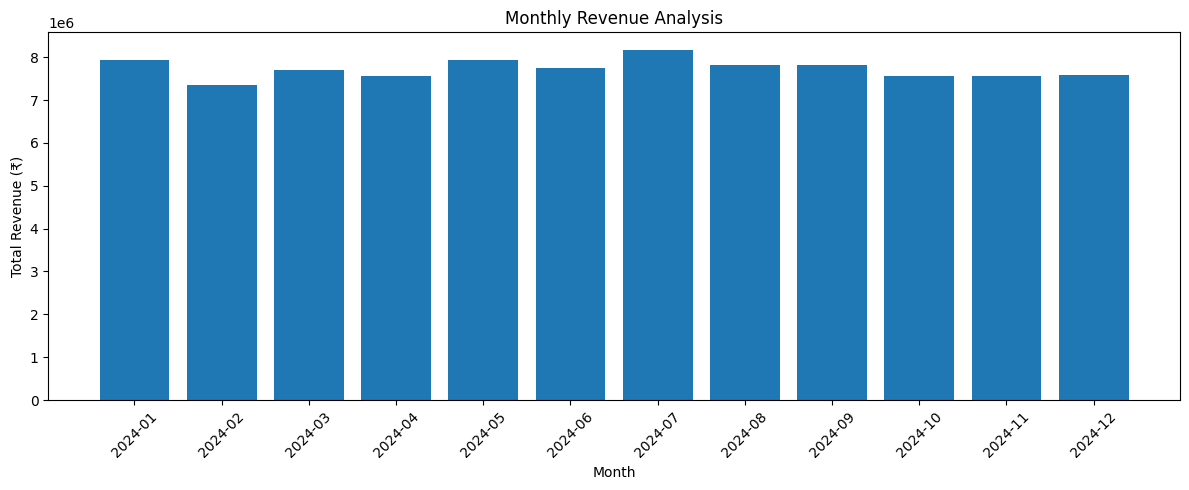

In [ ]:
import matplotlib.pyplot as plt

# Exclude rows with missing order dates
plot_data = monthly_revenue[
    monthly_revenue['Month'] != 'NaT'
].copy()

plt.figure(figsize=(12, 5))

plt.bar(
    plot_data['Month'],
    plot_data['Total_Revenue']
)

plt.title('Monthly Revenue Analysis')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Ratings greater than 5
df[df['Delivery_Rating'] > 5]['Delivery_Rating'].value_counts()

,count
Delivery_Rating,


In [ ]:
print("Data type:", df['Delivery_Rating'].dtype)

print("Maximum rating:", df['Delivery_Rating'].max())

print("Ratings greater than 5:")
print(df.loc[df['Delivery_Rating'] > 5, 'Delivery_Rating'].value_counts())

Data type: float64
Maximum rating: 5.0
Ratings greater than 5:
Series([], Name: count, dtype: int64)


Delivery Time Outlier Check (IQR Method)

In [ ]:
# Delivery time column
delivery_col = 'Delivery_Time_Min'

# Remove missing values for this analysis
delivery_valid = df[delivery_col].dropna()

# Q1, Q3, IQR
Q1 = delivery_valid.quantile(0.25)
Q3 = delivery_valid.quantile(0.75)
IQR = Q3 - Q1

# Upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Count potential outliers
outliers_above = (delivery_valid > upper_bound).sum()
outliers_below = (delivery_valid < lower_bound).sum()

print(f"Outliers below: {outliers_below}, Outliers above: {outliers_above}")

Q1: 45.0, Q3: 210.0, IQR: 165.0
Lower bound: -202.5, Upper bound: 457.5
Outliers below: 0, Outliers above: 0


order value outliers with IQR.

In [ ]:
# Order Value column
order_col = 'Order_Value'

# Remove missing values
order_valid = df[order_col].dropna()

# Q1, Q3, IQR
Q1 = order_valid.quantile(0.25)
Q3 = order_valid.quantile(0.75)
IQR = Q3 - Q1

# Upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Count potential outliers
outliers_above = (order_valid > upper_bound).sum()
outliers_below = (order_valid < lower_bound).sum()

print(f"Outliers below: {outliers_below}, Outliers above: {outliers_above}")

Q1: 673.0, Q3: 3494.0, IQR: 2821.0
Lower bound: -3558.5, Upper bound: 7725.5
Outliers below: 0, Outliers above: 0


Ensuring logical consistency (e.g., cancelled orders vs ratings)

In [ ]:
# Check cancelled orders with non-null ratings
cancelled_with_rating = df[
    (df['Order_Status'] == 'Cancelled') &
    (df['Delivery_Rating'].notna())
]

print(f"Cancelled orders with rating: {len(cancelled_with_rating)}")

# Show some examples
cancelled_with_rating[['Order_ID', 'Order_Status', 'Delivery_Rating']].head(10)

Cancelled orders with rating: 12561


,Order_ID,Order_Status,Delivery_Rating
3,ORD000004,Cancelled,2.0
36,ORD000037,Cancelled,1.0
38,ORD000039,Cancelled,2.0
49,ORD000050,Cancelled,1.0
54,ORD000055,Cancelled,5.0
60,ORD000061,Cancelled,5.0
73,ORD000074,Cancelled,3.0
81,ORD000082,Cancelled,5.0
90,ORD000091,Cancelled,1.0
94,ORD000095,Cancelled,1.0


In [ ]:
# Set rating to NaN for cancelled orders
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Rating'] = float('nan')

# Check result
cancelled_after = df['Order_Status'].eq('Cancelled').sum()
rating_after = df['Delivery_Rating'].notna().sum()

print(f"Total cancelled orders: {cancelled_after}")
print(f"Total non-null ratings after treatment: {rating_after}")

Total cancelled orders: 15036
Total non-null ratings after treatment: 70916


Distribution of order values and delivery time

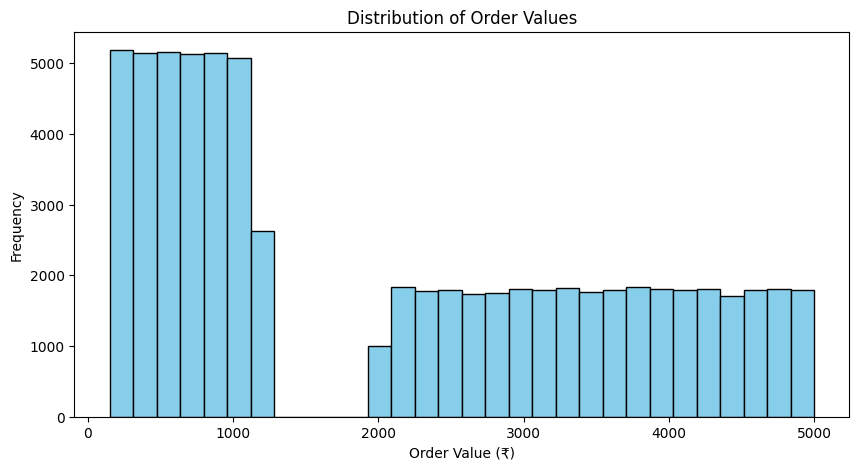

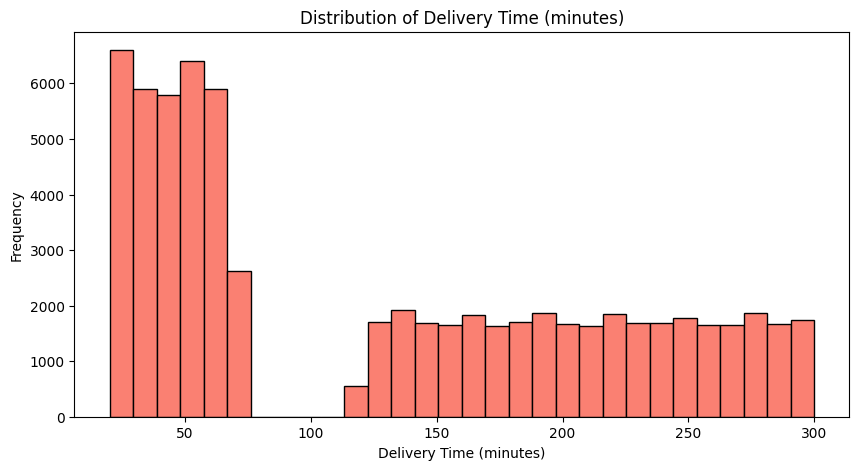

In [ ]:
import matplotlib.pyplot as plt

# Plotting Order Value Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['Order_Value'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Order Values')
plt.xlabel('Order Value (₹)')
plt.ylabel('Frequency')
plt.show()

# Plotting Delivery Time Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['Delivery_Time_Min'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.savefig('plot.png')  # This saves the plot as an image file.
plt.show()

In [ ]:
df.columns.to_list()

['Order_ID',
 'Customer_ID',
 'Customer_Age',
 'Customer_Gender',
 'City',
 'Area',
 'Restaurant_ID',
 'Restaurant_Name',
 'Cuisine_Type',
 'Order_Date',
 'Order_Time',
 'Delivery_Time_Min',
 'Distance_km',
 'Order_Value',
 'Discount_Applied',
 'Final_Amount',
 'Payment_Mode',
 'Order_Status',
 'Cancellation_Reason',
 'Delivery_Partner_ID',
 'Delivery_Rating',
 'Restaurant_Rating',
 'Order_Day',
 'Peak_Hour',
 'Profit_Margin']

City-wise and cuisine-wise order analysis


In [ ]:
# Orders by city
city_orders = df['City'].value_counts()

# Orders by cuisine type
cuisine_orders = df['Cuisine_Type'].value_counts()

print("Orders by City:")
print(city_orders)

print("\nOrders by Cuisine Type:")
print(cuisine_orders)

Orders by City:
City
Hyderabad    16884
Bangalore    16732
Delhi        16695
Mumbai       16493
Chennai      16470
Name: count, dtype: int64

Orders by Cuisine Type:
Cuisine_Type
Indian     16685
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64


In [ ]:
# Check missing values in City and Cuisine_Type

print("Missing values in City:",
      df['City'].isnull().sum())

print("Missing values in Cuisine_Type:",
      df['Cuisine_Type'].isnull().sum())

Missing values in City: 16726
Missing values in Cuisine_Type: 16885


In [ ]:
# Fill missing values with Unknown

df['City'] = df['City'].fillna('Unknown')

df['Cuisine_Type'] = df['Cuisine_Type'].fillna('Unknown')

# Verify missing values after treatment

print("Missing City:", df['City'].isnull().sum())

print("Missing Cuisine:",
      df['Cuisine_Type'].isnull().sum())

Missing City: 0
Missing Cuisine: 0


In [ ]:
print("Orders by City:")
print(df['City'].value_counts())

print("\nOrders by Cuisine:")
print(df['Cuisine_Type'].value_counts())

Orders by City:
City
Hyderabad    16884
Bangalore    16732
Unknown      16726
Delhi        16695
Mumbai       16493
Chennai      16470
Name: count, dtype: int64

Orders by Cuisine:
Cuisine_Type
Unknown    16885
Indian     16685
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64


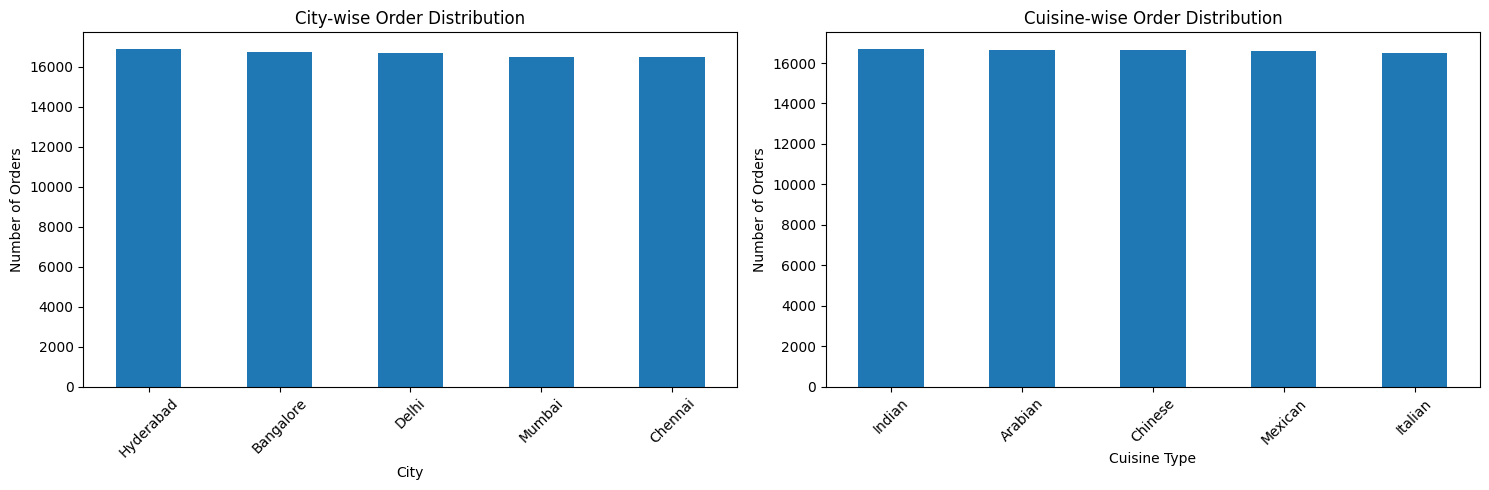

In [ ]:
import matplotlib.pyplot as plt

# Count orders by city and cuisine
city_counts = df['City'].value_counts()
cuisine_counts = df['Cuisine_Type'].value_counts()

# Create two bar charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# City-wise orders
city_counts.plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('City-wise Order Distribution')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

# Cuisine-wise orders
cuisine_counts.plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Cuisine-wise Order Distribution')
axes[1].set_xlabel('Cuisine Type')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

weekend & weekdays analysis

In [ ]:
# Convert Order_Date into datetime format
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'], errors='coerce'
)

# Create Weekday / Weekend column
df['Day_Type'] = df['Order_Date'].dt.dayofweek.map(
    lambda day: 'Weekend' if day >= 5 else 'Weekday'
)

# Check the new column
print(df['Day_Type'].value_counts())

Day_Type
Weekday    71632
Weekend    28368
Name: count, dtype: int64


In [ ]:
# Check the existing Order_Day values
print(df['Order_Day'].value_counts(dropna=False))

# Check missing dates
print("Missing Order_Date:",
      df['Order_Date'].isna().sum())

# Verify total orders
print("Total rows:", len(df))
print("Weekday + Weekend:",
      df['Day_Type'].value_counts().sum())

Order_Day
Weekday    71370
Weekend    28630
Name: count, dtype: int64
Missing Order_Date: 1014
Total rows: 100000
Weekday + Weekend: 100000


In [ ]:
# Compare the two columns
print(pd.crosstab(df['Order_Day'], df['Day_Type'], dropna=False))

# Check missing dates
print("Missing Order_Date:", df['Order_Date'].isna().sum())

# Check missing values in both day columns
print("Missing Order_Day:", df['Order_Day'].isna().sum())
print("Missing Day_Type:", df['Day_Type'].isna().sum())

Day_Type   Weekday  Weekend
Order_Day                  
Weekday      71370        0
Weekend        262    28368
Missing Order_Date: 1014
Missing Order_Day: 0
Missing Day_Type: 0


In [ ]:
# Find rows where Order_Day and Day_Type do not match
mismatch = df[
    df['Order_Day'] != df['Day_Type']
]

print("Total mismatched rows:", len(mismatch))

# Check whether those rows have missing dates
print("Missing dates in mismatched rows:",
      mismatch['Order_Date'].isna().sum())

# Display sample mismatched rows
display(
    mismatch[['Order_Date', 'Order_Day', 'Day_Type']].head(10)
)

Total mismatched rows: 262
Missing dates in mismatched rows: 262


,Order_Date,Order_Day,Day_Type
429,NaT,Weekend,Weekday
1170,NaT,Weekend,Weekday
1498,NaT,Weekend,Weekday
2037,NaT,Weekend,Weekday
2068,NaT,Weekend,Weekday
2301,NaT,Weekend,Weekday
2615,NaT,Weekend,Weekday
3389,NaT,Weekend,Weekday
3586,NaT,Weekend,Weekday
4097,NaT,Weekend,Weekday


In [ ]:
import numpy as np
import pandas as pd

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

# Extract day of week: Monday=0, Sunday=6
day_num = df['Order_Date'].dt.dayofweek

# Create Day_Type
df['Day_Type'] = np.where(
    day_num.isna(),
    df['Order_Day'],
    np.where(day_num >= 5, 'Weekend', 'Weekday')
)

In [ ]:
print(df['Day_Type'].value_counts(dropna=False))

print("\nMismatch count:",
      (df['Order_Day'] != df['Day_Type']).sum())

print("\nMissing Day_Type:",
      df['Day_Type'].isna().sum())

Day_Type
Weekday    71370
Weekend    28630
Name: count, dtype: int64

Mismatch count: 0

Missing Day_Type: 0


In [ ]:
# Weekend vs Weekday Demand Analysis

# Count orders for each day type
day_demand = df.groupby('Day_Type').agg(
    Total_Orders=('Order_ID', 'count'),
    Total_Revenue=('Final_Amount', 'sum'),
    Average_Order_Value=('Final_Amount', 'mean')
)

print(day_demand)

          Total_Orders  Total_Revenue  Average_Order_Value
Day_Type                                                  
Weekday          71370     62040654.0          1967.046734
Weekend          28630     24842012.0          1946.408525


Distance vs Delivery Delay Relationship

Correlation: 0.003


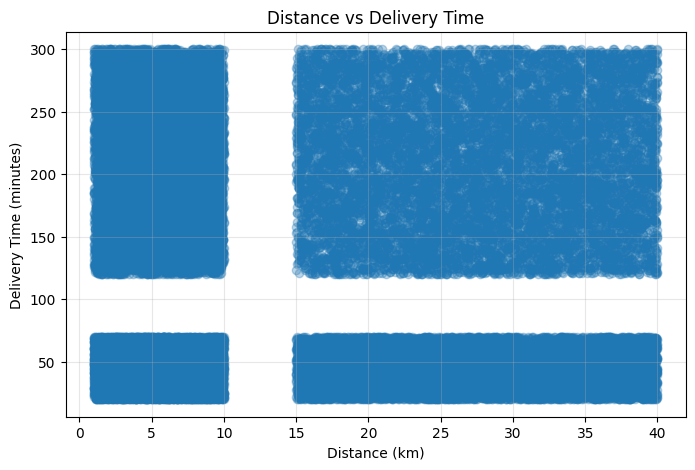

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Select required columns and remove missing values
plot_df = df[['Distance_km', 'Delivery_Time_Min']].dropna()

# Correlation
correlation = plot_df['Distance_km'].corr(
    plot_df['Delivery_Time_Min']
)

print(f"Correlation: {correlation:.3f}")

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df['Distance_km'],
    plot_df['Delivery_Time_Min'],
    alpha=0.3
)

plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True, alpha=0.3)
plt.show()

Cancellation reasons analysis

Cancellation_Reason
Late Delivery         3059
Customer Cancelled    2993
Restaurant Issue      2979
Name: count, dtype: int64


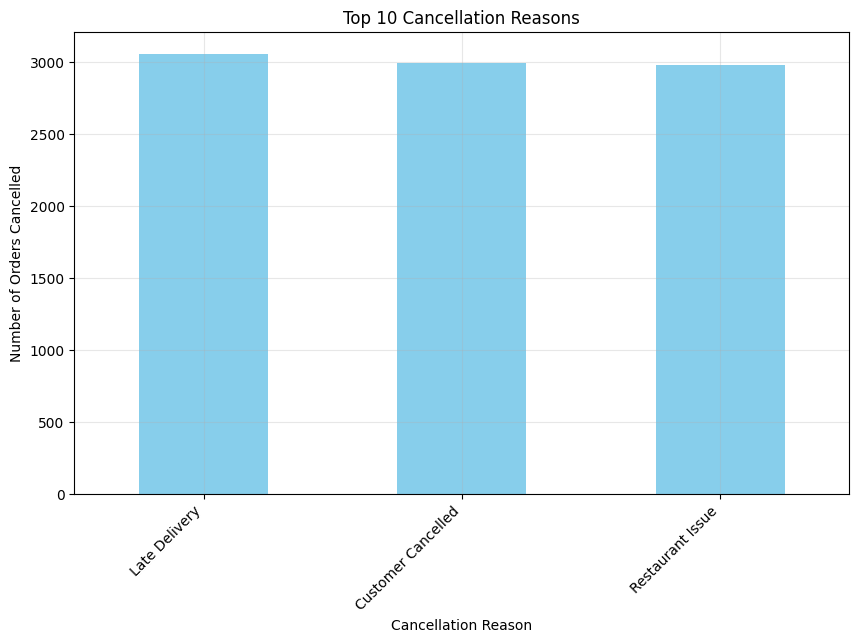

In [ ]:
import matplotlib.pyplot as plt

# Group by cancellation reason and count
cancellation_counts = df['Cancellation_Reason'].value_counts()

# Display top reasons
print(cancellation_counts.head(10))

# Plot top 10 reasons
plt.figure(figsize=(10, 6))
cancellation_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Cancellation Reasons')
plt.xlabel('Cancellation Reason')
plt.ylabel('Number of Orders Cancelled')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.show()

Correlation analysis among numeric features
  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select meaningful numeric features
numeric_cols = [
    'Customer_Age',
    'Delivery_Time_Min',
    'Distance_km',
    'Order_Value',
    'Discount_Applied',
    'Final_Amount',
    'Delivery_Rating',
    'Restaurant_Rating',
    'Profit_Margin'
]

# Create correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display correlation values
print(corr_matrix.round(2))

                   Customer_Age  Delivery_Time_Min  Distance_km  Order_Value  \
Customer_Age               1.00              -0.02         -0.0        -0.00   
Delivery_Time_Min         -0.02               1.00          0.0         0.00   
Distance_km               -0.00               0.00          1.0         0.00   
Order_Value               -0.00               0.00          0.0         1.00   
Discount_Applied           0.00              -0.00          0.0         0.00   
Final_Amount              -0.00              -0.00         -0.0         1.00   
Delivery_Rating           -0.00               0.00          0.0        -0.00   
Restaurant_Rating          0.00               0.00          0.0        -0.01   
Profit_Margin              0.00              -0.00          0.0        -0.00   

                   Discount_Applied  Final_Amount  Delivery_Rating  \
Customer_Age                   0.00         -0.00             -0.0   
Delivery_Time_Min             -0.00         -0.00          

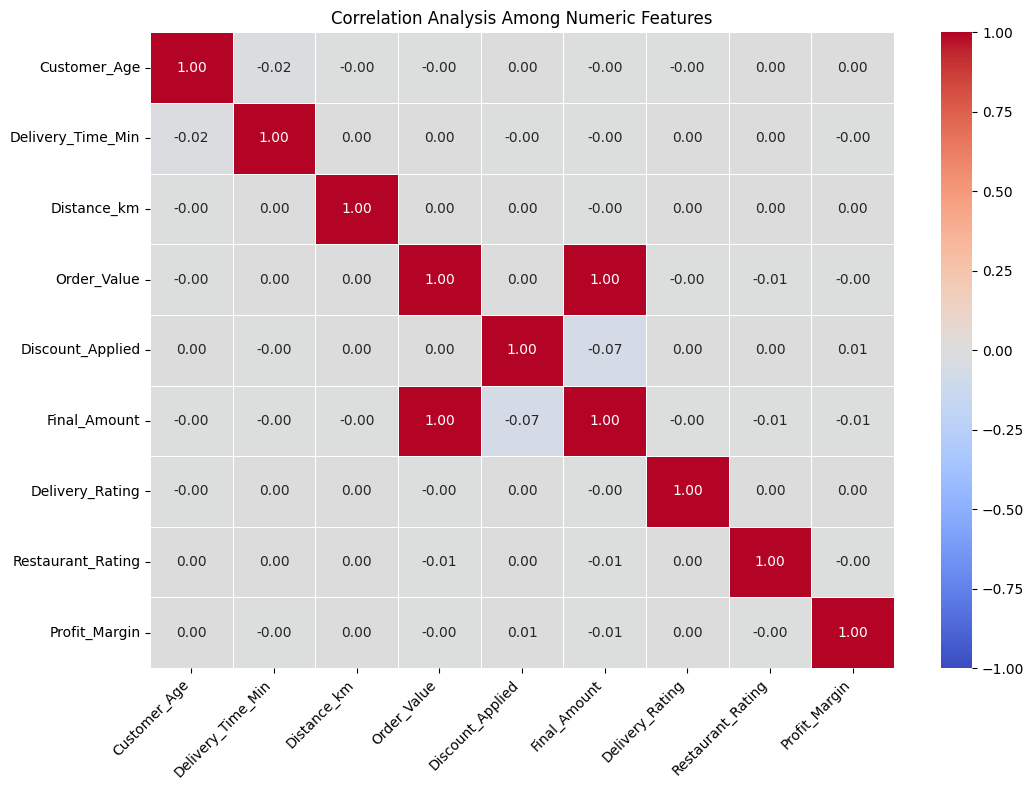

In [ ]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Correlation Analysis Among Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

feature engineering
---weekdays & weekends-order_day

In [ ]:
import numpy as np
import pandas as pd

# Make sure Order_Date is in datetime format
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

# Extract day number: Monday = 0, Sunday = 6
day_num = df['Order_Date'].dt.dayofweek

# Create the Day_Type feature
df['Day_Type'] = np.where(
    day_num.isna(),
    df['Order_Day'],
    np.where(day_num >= 5, 'Weekend', 'Weekday')
)

# Display the result
print(df[['Order_Date', 'Order_Day', 'Day_Type']].head())

  Order_Date Order_Day Day_Type
0 2024-10-20   Weekend  Weekend
1 2024-08-12   Weekday  Weekday
2 2024-12-08   Weekend  Weekend
3 2024-10-08   Weekday  Weekday
4 2024-02-04   Weekend  Weekend


In [ ]:
print(df['Day_Type'].value_counts())

print("Missing values:", df['Day_Type'].isna().sum())

Day_Type
Weekday    71370
Weekend    28630
Name: count, dtype: int64
Missing values: 0


FE-Peak hour indicator
>Order_Time data issue




profit margin percentage

In [ ]:
# Calculate profit margin percentage
df['Profit_Margin_Percentage'] = (df['Profit_Margin'] * 100)

# Check a few rows
print(df[['Order_ID', 'Profit_Margin', 'Profit_Margin_Percentage']].head())

    Order_ID  Profit_Margin  Profit_Margin_Percentage
0  ORD000001           0.13                      13.0
1  ORD000002           0.48                      48.0
2  ORD000003           0.08                       8.0
3  ORD000004           0.04                       4.0
4  ORD000005           0.12                      12.0


Delivery Time Category
Delivery Rating Category:

In [ ]:
# Define bins for delivery time (in minutes)
bins = [0, 30, 60, 120, np.inf]
labels = ['Fast', 'Moderate', 'Slow', 'Very Slow']

# Create a new column for delivery performance
df['Delivery_Performance'] = pd.cut(df['Delivery_Time_Min'], bins=bins, labels=labels, right=False)

# Check the result
print(df[['Order_ID', 'Delivery_Time_Min', 'Delivery_Performance']].head())

    Order_ID  Delivery_Time_Min Delivery_Performance
0  ORD000001              187.0            Very Slow
1  ORD000002               20.0                 Fast
2  ORD000003              207.0            Very Slow
3  ORD000004              143.0            Very Slow
4  ORD000005               51.0             Moderate


In [ ]:
# Define bins for rating (e.g., 1 to 5 scale)
rating_bins = [0, 2, 4, 5]
rating_labels = ['Low', 'Average', 'High']

df['Delivery_Rating_Category'] = pd.cut(df['Delivery_Rating'], bins=rating_bins, labels=rating_labels, right=True)

# Check the result
print(df[['Order_ID', 'Delivery_Rating', 'Delivery_Rating_Category']].head())

    Order_ID  Delivery_Rating Delivery_Rating_Category
0  ORD000001              5.0                     High
1  ORD000002              5.0                     High
2  ORD000003              4.0                  Average
3  ORD000004              2.0                      Low
4  ORD000005              2.0                      Low


Customer age groups

In [ ]:


# Define age bins
age_bins = [0, 18, 30, 45, 60, np.inf]
age_labels = ['Under 18', '18-30', '31-45', '46-60', 'Above 60']

# Create a new column for age group
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=age_bins, labels=age_labels, right=False)

# Check the output
print(df[['Order_ID', 'Customer_Age', 'Age_Group']].head())

    Order_ID  Customer_Age Age_Group
0  ORD000001          19.0     18-30
1  ORD000002           NaN       NaN
2  ORD000003           NaN       NaN
3  ORD000004           NaN       NaN
4  ORD000005          57.0     46-60


In [ ]:
median_age = df['Customer_Age'].median()
df['Customer_Age'] = df['Customer_Age'].fillna(median_age)

In [ ]:
# Define age bins
age_bins = [0, 18, 30, 45, 60, np.inf]
age_labels = ['Under 18', '18-30', '31-45', '46-60', 'Above 60']

# Create a new column for age group
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=age_bins, labels=age_labels, right=False)

# Check the output
print(df[['Order_ID', 'Customer_Age', 'Age_Group']].head())


    Order_ID  Customer_Age Age_Group
0  ORD000001          19.0     18-30
1  ORD000002          39.0     31-45
2  ORD000003          39.0     31-45
3  ORD000004          39.0     31-45
4  ORD000005          57.0     46-60


In [ ]:
print("Missing values:", df['Customer_Age'].isna().sum())

Missing values: 0


In [ ]:
df.to_csv("food_delivery_cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("food_delivery_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>